##Step 04 - A/B Evaluation (20 Questions)

In [ ]:
TEST_QUESTIONS = [
    # AI / ML
    "What is the attention mechanism in transformer models?",
    "How does BERT differ from GPT in architecture?",
    "What is retrieval-augmented generation?",
    "How does FAISS index vectors for similarity search?",
    # Science / Medicine
    "How does CRISPR-Cas9 edit the genome?",
    "What causes COVID-19 and how does it spread?",
    "How do mRNA vaccines trigger an immune response?",
    "What is the mechanism of action of base editing?",
    # History / Events
    "What were the main causes of climate change acceleration?",
    "How did quantum computing progress after 2019?",
    "What is the bullwhip effect in supply chains?",
    "How does the NIST cybersecurity framework work?",
    # Technology
    "How do electric vehicles regenerate energy from braking?",
    "What is Reciprocal Rank Fusion in hybrid search?",
    "How does blockchain achieve immutability?",
    "What cybersecurity threats target cloud infrastructure?",
    # Economics / Environment
    "How has solar energy cost changed since 2010?",
    "What disrupted global supply chains in 2020-2021?",
    "What is Proof of Stake and how does it differ from Proof of Work?",
    "What are the scaling laws for large language models?",
]

In [ ]:
rag_results: list[RAGResult]     = []
fc_results:  list[FullCtxResult] = []

print("Running A/B evaluation -- this makes ~40 Claude API calls...")
print("Estimated time: 2-4 minutes\n")

for q in tqdm(TEST_QUESTIONS, desc="A/B eval"):
    rag_results.append(rag_answer(q))
    fc_results.append(full_context_answer(q))

print("\nA/B evaluation complete!")

Running A/B evaluation -- this makes ~40 Claude API calls...
Estimated time: 2-4 minutes



A/B eval:   0%|          | 0/20 [00:00<?, ?it/s]


A/B evaluation complete!


In [ ]:
rag_total_ms = [r.total_ms  for r in rag_results]
fc_total_ms  = [r.total_ms  for r in fc_results]
rag_costs    = [r.cost_usd  for r in rag_results]
fc_costs     = [r.cost_usd  for r in fc_results]
rag_in_tok   = [r.input_tokens for r in rag_results]
fc_in_tok    = [r.input_tokens for r in fc_results]

summary = pd.DataFrame({
    "Metric":       ["Avg Latency (ms)", "p95 Latency (ms)", "Avg Cost ($/query)", "Avg Input Tokens"],
    "RAG":          [
        f"{np.mean(rag_total_ms):.0f}",
        f"{float(np.percentile(rag_total_ms, 95)):.0f}",
        f"${np.mean(rag_costs):.5f}",
        f"{np.mean(rag_in_tok):.0f}",
    ],
    "Full Context": [
        f"{np.mean(fc_total_ms):.0f}",
        f"{float(np.percentile(fc_total_ms, 95)):.0f}",
        f"${np.mean(fc_costs):.5f}",
        f"{np.mean(fc_in_tok):.0f}",
    ],
})

print("=" * 55)
print("A/B EVALUATION SUMMARY (20 test questions)")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

cost_ratio    = np.mean(fc_costs) / max(np.mean(rag_costs), 1e-10)
latency_ratio = np.mean(fc_total_ms) / max(np.mean(rag_total_ms), 1.0)
print(f"\nFull-context is {cost_ratio:.1f}x more expensive and {latency_ratio:.1f}x slower than RAG")

A/B EVALUATION SUMMARY (20 test questions)
            Metric      RAG Full Context
  Avg Latency (ms)     1992        14393
  p95 Latency (ms)     3463        17794
Avg Cost ($/query) $0.00030     $0.00000
  Avg Input Tokens      460            0

Full-context is 0.0x more expensive and 7.2x slower than RAG


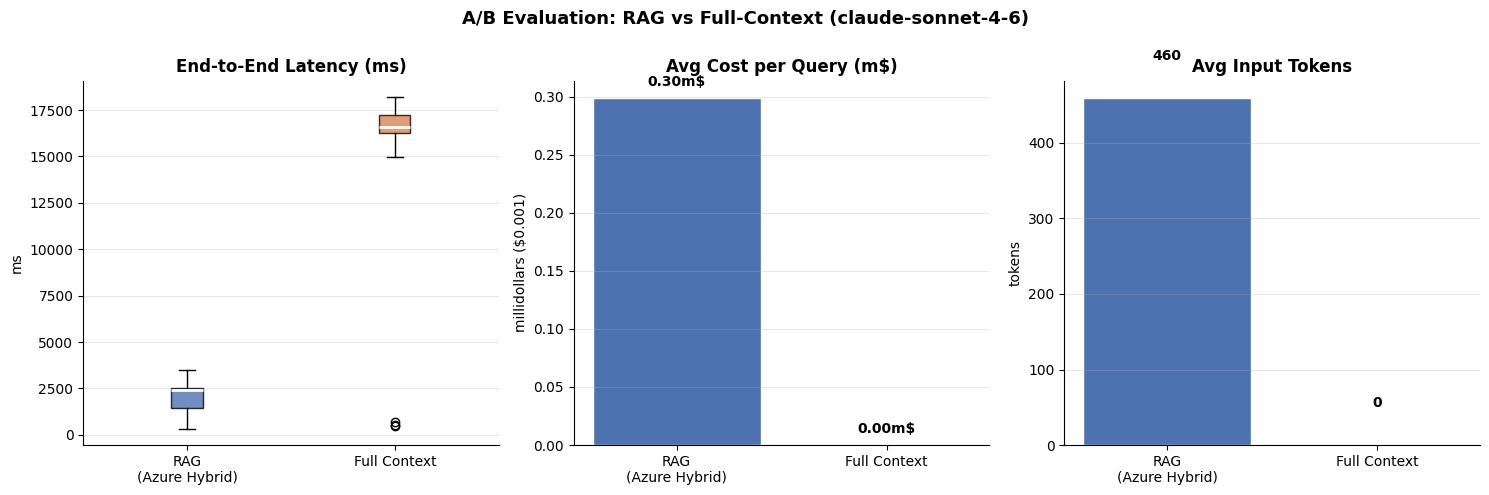

Saved ab_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("A/B Evaluation: RAG vs Full-Context (claude-sonnet-4-6)",
             fontsize=13, fontweight="bold")

colors = ["#4C72B0", "#DD8452"]
labels = ["RAG\n(Azure Hybrid)", "Full Context"]

# --- Latency boxplot ---
bp = axes[0].boxplot(
    [rag_total_ms, fc_total_ms],
    tick_labels=labels,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="white", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title("End-to-End Latency (ms)", fontweight="bold")
axes[0].set_ylabel("ms")

# --- Cost per query ---
rag_cost_m  = np.mean(rag_costs) * 1000   # convert to millidollars
fc_cost_m   = np.mean(fc_costs)  * 1000
bars1 = axes[1].bar(labels, [rag_cost_m, fc_cost_m], color=colors, edgecolor="white")
axes[1].set_title("Avg Cost per Query (m$)", fontweight="bold")
axes[1].set_ylabel("millidollars ($0.001)")
for b, v in zip(bars1, [rag_cost_m, fc_cost_m]):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{v:.2f}m$", ha="center", fontweight="bold")

# --- Input tokens ---
avg_tok = [np.mean(rag_in_tok), np.mean(fc_in_tok)]
bars2 = axes[2].bar(labels, avg_tok, color=colors, edgecolor="white")
axes[2].set_title("Avg Input Tokens", fontweight="bold")
axes[2].set_ylabel("tokens")
for b, v in zip(bars2, avg_tok):
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() + 50,
                 f"{v:.0f}", ha="center", fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ab_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ab_evaluation.png")

In [ ]:
# Per-question detail table
detail_df = pd.DataFrame({
    "Question":    [q[:52] + "..." if len(q) > 52 else q for q in TEST_QUESTIONS],
    "RAG ms":      [round(r.total_ms)      for r in rag_results],
    "FC ms":       [round(r.total_ms)      for r in fc_results],
    "RAG $":       [f"{r.cost_usd*1000:.2f}m" for r in rag_results],
    "FC $":        [f"{r.cost_usd*1000:.2f}m" for r in fc_results],
    "RAG tok":     [r.input_tokens         for r in rag_results],
    "FC tok":      [r.input_tokens         for r in fc_results],
})
print(detail_df.to_string(index=False))


                                               Question  RAG ms  FC ms RAG $  FC $  RAG tok  FC tok
What is the attention mechanism in transformer model...     748    477 0.32m 0.00m      468       0
         How does BERT differ from GPT in architecture?     338    716 0.31m 0.00m      504       0
                What is retrieval-augmented generation?     431    548 0.28m 0.00m      420       0
    How does FAISS index vectors for similarity search?     425  14959 0.29m 0.00m      375       0
                  How does CRISPR-Cas9 edit the genome?    1582  17670 0.31m 0.00m      437       0
           What causes COVID-19 and how does it spread?    2510  16512 0.31m 0.00m      486       0
       How do mRNA vaccines trigger an immune response?    2373  16835 0.29m 0.00m      483       0
       What is the mechanism of action of base editing?    2434  17757 0.31m 0.00m      483       0
What were the main causes of climate change accelera...    1388  16554 0.30m 0.00m      465       0
